<a href="https://colab.research.google.com/github/Anvarjondevelop/ai_foundation/blob/main/PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
print(torch.__version__)

2.11.0+cu128


In [3]:
print("Cuda GPU available", torch.cuda.is_available())

Cuda GPU available True


In [4]:
scalar = torch.tensor(5)  # 0D
print('scalar:', scalar)
print("Shape:", scalar.shape)
print('Number of Dimensions:', scalar.ndim)
print('Size:', scalar.size())

scalar: tensor(5)
Shape: torch.Size([])
Number of Dimensions: 0
Size: torch.Size([])


In [5]:
vector = torch.tensor([1, 2, 3])  # 1D
print("vector:", vector)
print("Shape:", vector.shape)
print('Number of Dimensions:', vector.ndim)
print('Size:', vector.size())

vector: tensor([1, 2, 3])
Shape: torch.Size([3])
Number of Dimensions: 1
Size: torch.Size([3])


In [6]:
MATRIX = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])  # 2D
print('MATRIX:', MATRIX)
print('Shape:', MATRIX.shape)
print('Number of Dimensions:', MATRIX.ndim)


tensor3d = torch.stack([MATRIX, MATRIX + 10])  # 3D
print('tensor3d:', tensor3d)
print('Shape:', tensor3d.shape)  # [2, 2, 3] | 2 matrices
print('Number of Dimensions:', tensor3d.ndim)

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Number of Dimensions: 2
tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
Shape: torch.Size([2, 2, 3])
Number of Dimensions: 3


In [7]:
random_numbers = torch.rand(2, 3)
print('Random Numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Device of random_numbers:', random_numbers.device)

print('Zeros:', torch.zeros(3, 3))

print('Ones:', torch.ones(2, 4))

Random Numbers: tensor([[0.1721, 0.0990, 0.8621],
        [0.8102, 0.9603, 0.4134]])
Data type: torch.float32
Device of random_numbers: cpu
Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [8]:
x = torch.tensor([[1, 2],
                   [3, 4]])
y = torch.tensor([[5, 6],
                   [7, 8]])

print('Addition:', x + y)
print('========')

print('Multiplication:', x * y)
print('=======')

print('Matrix @ multiplcation:', x @ y)

Addition: tensor([[ 6,  8],
        [10, 12]])
Multiplication: tensor([[ 5, 12],
        [21, 32]])
Matrix @ multiplcation: tensor([[19, 22],
        [43, 50]])


In [9]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)


Using device: cuda


(40, 40, 10, 10)

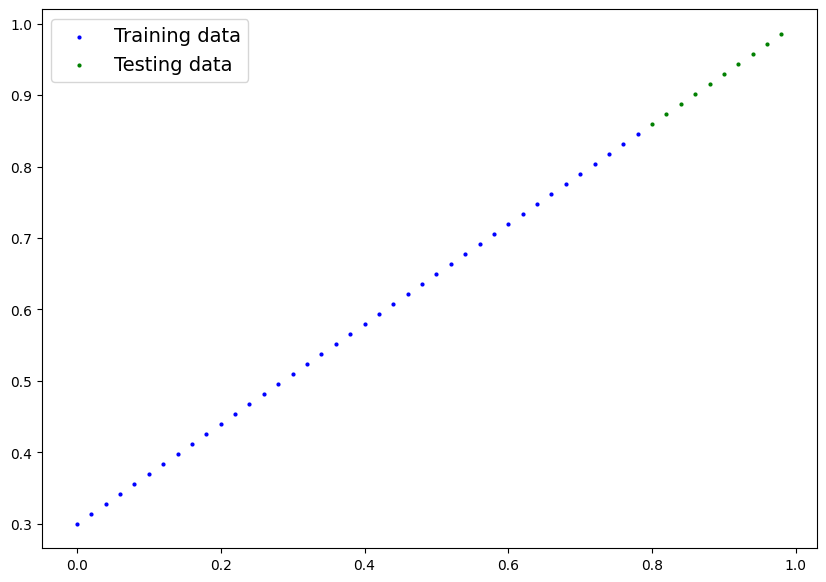

In [10]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    plt.legend(prop={'size': 14})

plot_predictions()


In [11]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

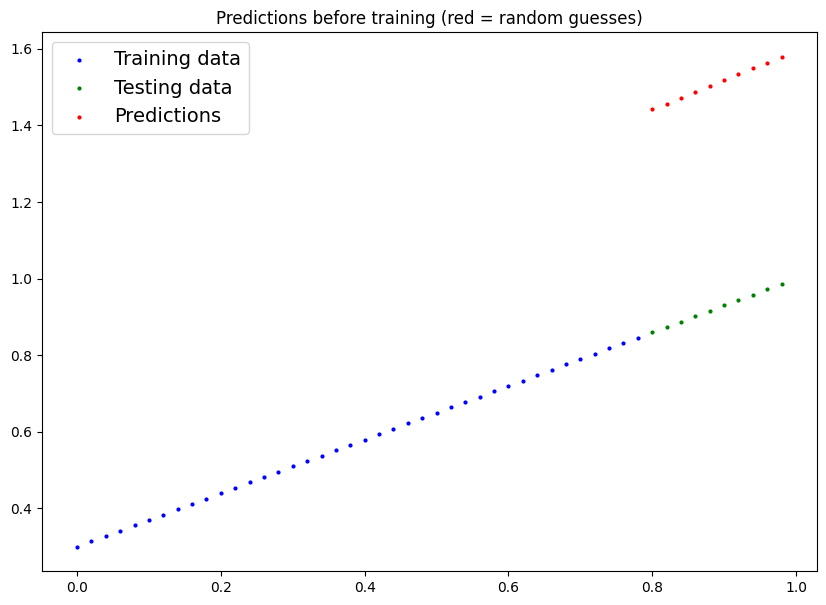

In [16]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

model_1.eval()
with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)
plt.title("Predictions before training (red = random guesses)")

In [19]:
epochs = 100
for epoch in range(epochs):
    ### Training
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.5551779866218567 | Test loss: 0.5739762187004089


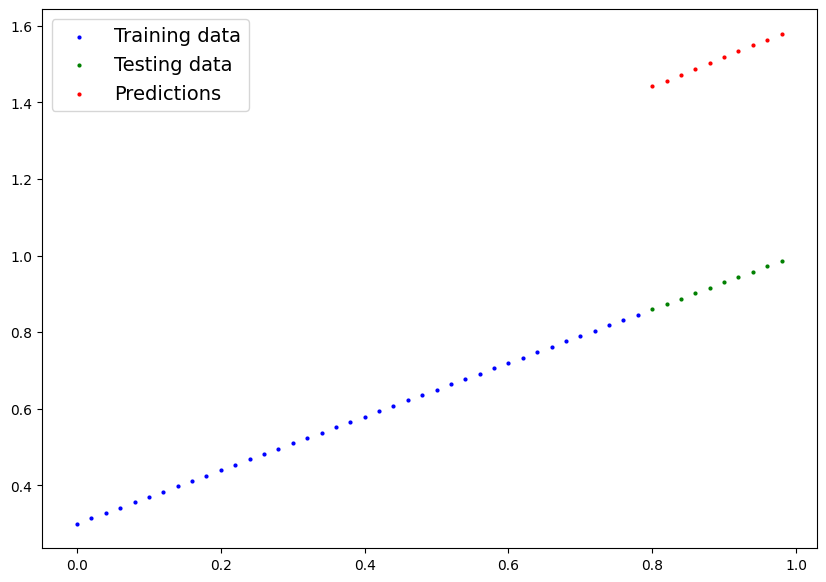

In [14]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

plot_predictions(predictions=y_preds)